In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

dataset_path = (
    PROJECT_ROOT
    / "data/processed/validated_multilingual_grievances.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\delll\\Desktop\\SmartRoute\\data\\processed\\validated_multilingual_grievances.csv'

In [2]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\delll\Desktop\SmartRoute"
)

csv_files = list(PROJECT_ROOT.rglob("*.csv"))

for file in csv_files:
    print(file)

C:\Users\delll\Desktop\SmartRoute\data\raw\english_complaints.csv
C:\Users\delll\Desktop\SmartRoute\data\raw\hindi_complaints.csv
C:\Users\delll\Desktop\SmartRoute\data\raw\hinglish_complaints.csv
C:\Users\delll\Desktop\SmartRoute\data\raw\multilingual_grievances.csv
C:\Users\delll\Desktop\SmartRoute\data\raw\seed_complaints.csv


In [3]:
import pandas as pd

raw_path = (
    PROJECT_ROOT
    / "data/raw/multilingual_grievances.csv"
)

df = pd.read_csv(raw_path)

df["text_length"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().str.len()

processed_path = (
    PROJECT_ROOT
    / "data/processed/validated_multilingual_grievances.csv"
)

processed_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(
    processed_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset recovered and saved successfully!")
print("Shape:", df.shape)
print("Saved at:", processed_path)

Dataset recovered and saved successfully!
Shape: (3600, 9)
Saved at: C:\Users\delll\Desktop\SmartRoute\data\processed\validated_multilingual_grievances.csv


In [5]:
import numpy as np

rng = np.random.default_rng(42)
group_to_split = {}

for category in sorted(df["category"].unique()):
    for language in sorted(df["language"].unique()):

        subset = df[
            (df["category"] == category)
            & (df["language"] == language)
        ]

        groups = (
            subset["template_group"]
            .drop_duplicates()
            .astype(str)
            .to_numpy(dtype=object, copy=True)
        )

        groups = rng.permutation(groups)

        for group in groups[:7]:
            group_to_split[group] = "train"

        for group in groups[7:8]:
            group_to_split[group] = "validation"

        for group in groups[8:]:
            group_to_split[group] = "test"

df["split"] = (
    df["template_group"]
    .astype(str)
    .map(group_to_split)
)

print(df["split"].value_counts())

split
train         2520
test           720
validation     360
Name: count, dtype: int64


In [6]:
assert df["split"].isnull().sum() == 0
assert df.groupby("template_group")["split"].nunique().max() == 1

split_balance = pd.crosstab(
    [df["category"], df["language"]],
    df["split"]
)

print(split_balance)

assert (split_balance["train"] == 105).all()
assert (split_balance["validation"] == 15).all()
assert (split_balance["test"] == 30).all()

print("\n✅ Split is balanced and contains no template leakage!")

split                        test  train  validation
category           language                         
Account Issue      English     30    105          15
                   Hindi       30    105          15
                   Hinglish    30    105          15
Cancellation Issue English     30    105          15
                   Hindi       30    105          15
                   Hinglish    30    105          15
Delivery Issue     English     30    105          15
                   Hindi       30    105          15
                   Hinglish    30    105          15
Fraud/Security     English     30    105          15
                   Hindi       30    105          15
                   Hinglish    30    105          15
Payment Issue      English     30    105          15
                   Hindi       30    105          15
                   Hinglish    30    105          15
Product Issue      English     30    105          15
                   Hindi       30    105      

In [7]:
train_df = df[df["split"] == "train"].copy()
validation_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df["text"]
y_train = train_df["category"]

X_validation = validation_df["text"]
y_validation = validation_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("Testing records:", len(test_df))

Training records: 2520
Validation records: 360
Testing records: 720


In [8]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

character_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

baseline_model = Pipeline([
    (
        "features",
        FeatureUnion([
            ("word_tfidf", word_tfidf),
            ("character_tfidf", character_tfidf)
        ])
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print("Baseline pipeline created successfully!")

Baseline pipeline created successfully!


In [9]:
import time

start_time = time.perf_counter()

baseline_model.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

print("✅ Baseline model trained successfully!")
print(f"Training time: {training_time:.2f} seconds")

✅ Baseline model trained successfully!
Training time: 0.85 seconds


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

validation_predictions = baseline_model.predict(X_validation)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0
)

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Weighted precision:  {precision:.4f}")
print(f"Weighted recall:     {recall:.4f}")
print(f"Weighted F1-score:   {f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_validation,
        validation_predictions,
        zero_division=0
    )
)

Validation accuracy: 0.7944
Weighted precision:  0.8420
Weighted recall:     0.7944
Weighted F1-score:   0.7972

Classification report:
                    precision    recall  f1-score   support

     Account Issue       0.66      1.00      0.80        45
Cancellation Issue       1.00      0.67      0.80        45
    Delivery Issue       0.51      0.67      0.58        45
    Fraud/Security       1.00      0.67      0.80        45
     Payment Issue       0.82      0.69      0.75        45
     Product Issue       1.00      0.67      0.80        45
      Refund Issue       1.00      1.00      1.00        45
Return/Replacement       0.75      1.00      0.86        45

          accuracy                           0.79       360
         macro avg       0.84      0.79      0.80       360
      weighted avg       0.84      0.79      0.80       360



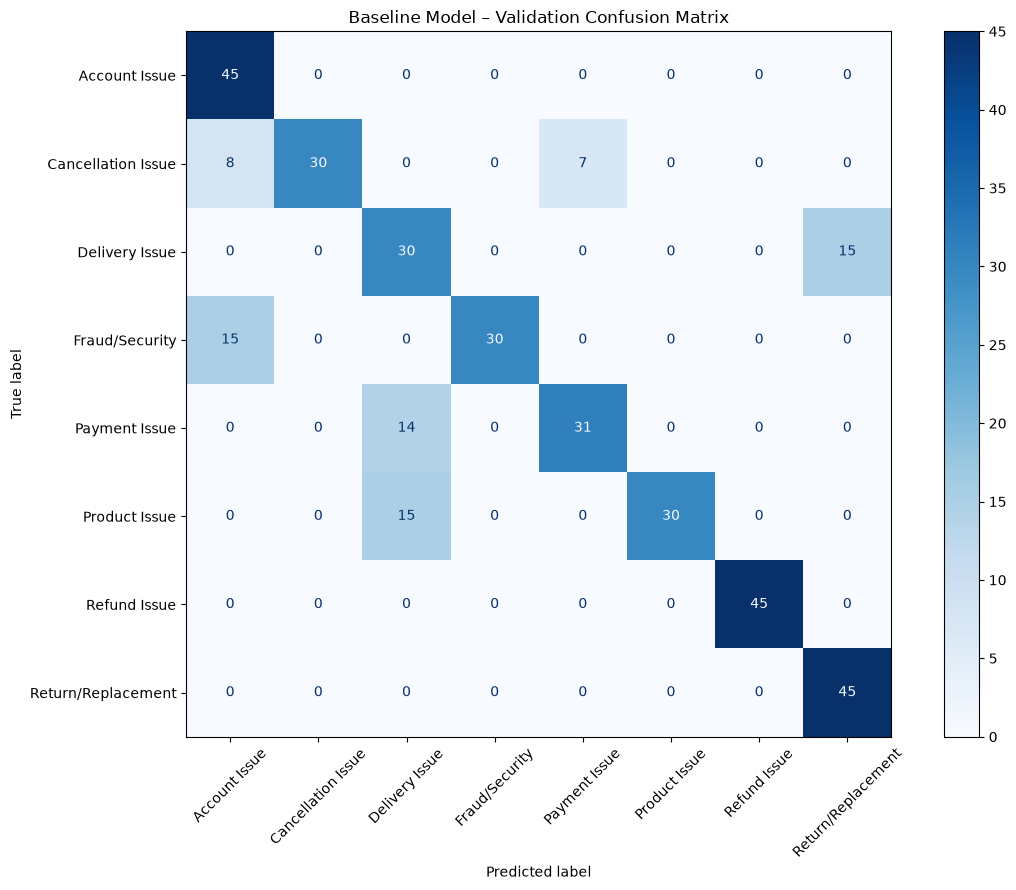

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = sorted(df["category"].unique())

fig, ax = plt.subplots(figsize=(12, 9))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("Baseline Model – Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
language_results = []

for language in ["English", "Hindi", "Hinglish"]:
    language_mask = validation_df["language"] == language

    actual = y_validation[language_mask]
    predicted = validation_predictions[language_mask]

    lang_precision, lang_recall, lang_f1, _ = (
        precision_recall_fscore_support(
            actual,
            predicted,
            average="weighted",
            zero_division=0
        )
    )

    language_results.append({
        "language": language,
        "accuracy": accuracy_score(actual, predicted),
        "precision": lang_precision,
        "recall": lang_recall,
        "f1_score": lang_f1
    })

language_metrics_df = pd.DataFrame(language_results)

language_metrics_df.round(4)

,language,accuracy,precision,recall,f1_score
0,English,1.0000,1.0000,1.0000,1.0000
1,Hindi,0.5083,0.3775,0.5083,0.4150
2,Hinglish,0.8750,0.8125,0.8750,0.8333


In [13]:
validation_results = validation_df[
    [
        "complaint_id",
        "text",
        "language",
        "category"
    ]
].copy()

validation_results["predicted_category"] = validation_predictions
validation_results["correct"] = (
    validation_results["category"]
    == validation_results["predicted_category"]
)

mistakes_df = validation_results[
    ~validation_results["correct"]
].copy()

print("Total validation mistakes:", len(mistakes_df))

mistakes_df[
    [
        "text",
        "language",
        "category",
        "predicted_category"
    ]
].head(20)

Total validation mistakes: 74


,text,language,category,predicted_category
41,"Hello, mujhe wrong product deliver hua.",Hinglish,Product Issue,Delivery Issue
71,"नमस्ते, कूरियर वाले ने पैकेज देने से मना कर दि...",Hindi,Delivery Issue,Return/Replacement
117,"कृपया मदद करें, ऑर्डर में पेमेंट अभी भी पेंडिं...",Hindi,Payment Issue,Delivery Issue
158,मुझे सहायता चाहिए क्योंकि कूरियर वाले ने पैकेज...,Hindi,Delivery Issue,Return/Replacement
259,यह बहुत जरूरी है: कूरियर वाले ने पैकेज देने से...,Hindi,Delivery Issue,Return/Replacement
467,Ye urgent hai: mujhe wrong product deliver hua...,Hinglish,Product Issue,Delivery Issue
545,"कृपया मदद करें, मैं अपना ऑर्डर रद्द नहीं कर पा...",Hindi,Cancellation Issue,Payment Issue
633,"Please help, mujhe wrong product deliver hua. ...",Hinglish,Product Issue,Delivery Issue
638,"Please help, mujhe wrong product deliver hua. ...",Hinglish,Product Issue,Delivery Issue
651,मुझे सहायता चाहिए क्योंकि मैं अपना ऑर्डर रद्द ...,Hindi,Cancellation Issue,Account Issue


In [16]:
CATEGORIES = (
    df[["category", "department"]]
    .drop_duplicates()
    .set_index("category")["department"]
    .to_dict()
)

DEFAULT_PRIORITY = (
    df[["category", "priority"]]
    .drop_duplicates()
    .set_index("category")["priority"]
    .to_dict()
)

print("Department mapping:")
print(CATEGORIES)

print("\nPriority mapping:")
print(DEFAULT_PRIORITY)

Department mapping:
{'Payment Issue': 'Payments Team', 'Refund Issue': 'Refund Team', 'Fraud/Security': 'Security Team', 'Delivery Issue': 'Logistics Team', 'Cancellation Issue': 'Order Management', 'Account Issue': 'Account Support', 'Return/Replacement': 'Returns Team', 'Product Issue': 'Product Support'}

Priority mapping:
{'Payment Issue': 'High', 'Refund Issue': 'High', 'Fraud/Security': 'Critical', 'Delivery Issue': 'Medium', 'Cancellation Issue': 'Medium', 'Account Issue': 'Medium', 'Return/Replacement': 'Medium', 'Product Issue': 'High'}


In [17]:
import time

start_time = time.perf_counter()

test_predictions = baseline_model.predict(X_test)
test_probabilities = baseline_model.predict_proba(X_test)

prediction_time = time.perf_counter() - start_time
average_latency_ms = (prediction_time / len(X_test)) * 1000

test_accuracy = accuracy_score(y_test, test_predictions)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

print(f"Test accuracy:       {test_accuracy:.4f}")
print(f"Weighted precision:  {test_precision:.4f}")
print(f"Weighted recall:     {test_recall:.4f}")
print(f"Weighted F1-score:   {test_f1:.4f}")
print(f"Average latency:     {average_latency_ms:.4f} ms/complaint")

print("\nTest classification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

Test accuracy:       0.8278
Weighted precision:  0.8514
Weighted recall:     0.8278
Weighted F1-score:   0.8305
Average latency:     0.4291 ms/complaint

Test classification report:
                    precision    recall  f1-score   support

     Account Issue       0.58      0.92      0.71        90
Cancellation Issue       0.83      0.83      0.83        90
    Delivery Issue       0.79      0.64      0.71        90
    Fraud/Security       0.90      0.67      0.76        90
     Payment Issue       1.00      0.83      0.91        90
     Product Issue       0.88      0.83      0.86        90
      Refund Issue       1.00      1.00      1.00        90
Return/Replacement       0.82      0.89      0.86        90

          accuracy                           0.83       720
         macro avg       0.85      0.83      0.83       720
      weighted avg       0.85      0.83      0.83       720



In [18]:
test_results = test_df[
    [
        "complaint_id",
        "text",
        "language",
        "category",
        "department",
        "priority"
    ]
].copy()

test_results["predicted_category"] = test_predictions
test_results["confidence"] = test_probabilities.max(axis=1)
test_results["correct"] = (
    test_results["category"]
    == test_results["predicted_category"]
)

test_results["predicted_department"] = (
    test_results["predicted_category"].map(CATEGORIES)
)

test_results["predicted_priority"] = (
    test_results["predicted_category"].map(DEFAULT_PRIORITY)
)

test_results["requires_human_review"] = (
    test_results["confidence"] < 0.60
)

test_results.head()

,complaint_id,text,language,category,department,priority,predicted_category,confidence,correct,predicted_department,predicted_priority,requires_human_review
0,HIN_0141,"नमस्ते, मेरी खरीदारी के लिए गलत राशि ली गई। मु...",Hindi,Payment Issue,Payments Team,High,Payment Issue,0.251620,True,Payments Team,High,True
1,HIN_0402,मुझे सहायता चाहिए क्योंकि रिफंड गलत पेमेंट माध...,Hindi,Refund Issue,Refund Team,High,Refund Issue,0.244905,True,Refund Team,High,True
4,ENG_0212,My package is stuck at the same location Pleas...,English,Delivery Issue,Logistics Team,Medium,Delivery Issue,0.752392,True,Logistics Team,Medium,False
9,HIN_0543,ऐप में कैंसलेशन का विकल्प नहीं दिख रहा है। मुझ...,Hindi,Cancellation Issue,Order Management,Medium,Cancellation Issue,0.480839,True,Order Management,Medium,True
13,ENG_0033,The payment failed but money was taken from my...,English,Payment Issue,Payments Team,High,Payment Issue,0.650876,True,Payments Team,High,False


In [19]:
import json
import joblib

model_path = (
    PROJECT_ROOT
    / "models/baseline/tfidf_logistic_regression.joblib"
)

metrics_path = (
    PROJECT_ROOT
    / "outputs/reports/baseline_metrics.json"
)

predictions_path = (
    PROJECT_ROOT
    / "outputs/reports/baseline_test_predictions.csv"
)

model_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(baseline_model, model_path)

baseline_metrics = {
    "model": "TF-IDF + Logistic Regression",
    "test_records": int(len(test_df)),
    "accuracy": float(test_accuracy),
    "weighted_precision": float(test_precision),
    "weighted_recall": float(test_recall),
    "weighted_f1": float(test_f1),
    "average_latency_ms": float(average_latency_ms),
    "human_review_threshold": 0.60,
    "human_review_count": int(
        test_results["requires_human_review"].sum()
    )
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        baseline_metrics,
        file,
        indent=4,
        ensure_ascii=False
    )

test_results.to_csv(
    predictions_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Baseline model and results saved successfully!")
print("Model:", model_path)
print("Metrics:", metrics_path)
print("Predictions:", predictions_path)

✅ Baseline model and results saved successfully!
Model: C:\Users\delll\Desktop\SmartRoute\models\baseline\tfidf_logistic_regression.joblib
Metrics: C:\Users\delll\Desktop\SmartRoute\outputs\reports\baseline_metrics.json
Predictions: C:\Users\delll\Desktop\SmartRoute\outputs\reports\baseline_test_predictions.csv


In [20]:
print("OFFICIAL BASELINE RESULTS")
print("-" * 35)
print(f"Test accuracy:      {test_accuracy:.4f}")
print(f"Weighted precision: {test_precision:.4f}")
print(f"Weighted recall:    {test_recall:.4f}")
print(f"Weighted F1-score:  {test_f1:.4f}")
print(f"Average latency:    {average_latency_ms:.4f} ms")
print(
    "Human review cases:",
    test_results["requires_human_review"].sum()
)

OFFICIAL BASELINE RESULTS
-----------------------------------
Test accuracy:      0.8278
Weighted precision: 0.8514
Weighted recall:    0.8278
Weighted F1-score:  0.8305
Average latency:    0.4291 ms
Human review cases: 437
